# SADCP from a VmDas STA file — Google Colab long version

This is the **Google Colab long/diagnostic version** of the SADCP processing workflow.

It reads ShipADCP data from Teledyne RD Instruments, applies the basic QC, shows the individual QC diagnostics, plots the cleaned currents, and can export the QC'd data.

It supports **WH600** and **OS150** VmDas STA (Short Term Average) files.

Use this long version when teaching, inspecting, or troubleshooting the QC in detail. For routine processing, the shorter Colab notebook is usually more convenient.

The workflow is designed for users with little or no Python experience:

1. run the installation cell,
2. upload one `.STA` file,
3. choose the instrument and other user settings,
4. run the remaining cells from top to bottom,
5. inspect the ship track, raw-current plots, individual QC diagnostics, combined QC mask, and QC'd currents,
6. optionally export and download CSV/NetCDF/JPG results.

To run a cell, press **Shift+Enter** or click the play button.

The sign `#` means "comment"; rows beginning with `#` are not executed.

To edit a text cell, double click in it.

To edit a code cell, click once in it.


## 0. Colab setup

### Step 1 — install the required Python packages

Run the next cell once when you start a new Colab session.

Colab already contains many scientific Python packages. The command below installs the additional packages used by this notebook.

The installation can take a little while. Warnings about restarting the runtime can normally be ignored unless Colab explicitly asks you to restart.


In [ ]:
# COLAB: install packages used by the SADCP notebook
%pip install -q cmocean cartopy xarray scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 90.7 MB/s eta 0:00:00


## 1. Upload the STA file

Run the next cell. A **Choose Files** button will appear.

Select **one Teledyne VmDas `.STA` file**.

The uploaded STA file is stored only in the temporary Colab session and disappears when the runtime is closed.


In [ ]:
# COLAB: upload one STA file
from google.colab import files

print("Select one Teledyne VmDas .STA file")
uploaded = files.upload()

uploaded_names = list(uploaded.keys())
uploaded_sta_files = [
    name for name in uploaded_names if name.upper().endswith(".STA")
]

print("\nUploaded files:")
for name in uploaded_names:
    print(" ", name)

if len(uploaded_sta_files) == 0:
    raise FileNotFoundError(
        "No .STA file was uploaded. Run this cell again and select one .STA file."
    )

if len(uploaded_sta_files) > 1:
    raise RuntimeError(
        "More than one .STA file was uploaded. "
        "For this beginner workflow, restart the runtime and upload only one STA file."
    )


Select one Teledyne VmDas .STA file


Saving ADCPOS150_77SE_2026_19_004_000000.STA to ADCPOS150_77SE_2026_19_004_000000.STA

Uploaded files:
  ADCPOS150_77SE_2026_19_004_000000.STA


## 2. Load packages and the built-in STA reader

Run the next two cells.

The first loads the standard packages used by the notebook.

The second contains the STA reader. It is part of the notebook and normally does not need to be edited.


In [ ]:
from pathlib import Path
from datetime import datetime
from copy import copy

import numpy as np
import matplotlib.pyplot as plt
import cmocean

def finish_plot(fig, ax, suffix):
    # Vertical axis
    if use_ymax:
        ax.set_ylim(plot_ymax, 0)
    else:
        ax.invert_yaxis()

    fig.tight_layout()

    if save_plots:
        jpg_file = STA_FILE.with_name(f"{STA_FILE.stem}{suffix}.jpg")
        fig.savefig(jpg_file, dpi=jpg_dpi, bbox_inches="tight")
        print(f"Saved: {jpg_file}")

    plt.show()


In [ ]:
"""Reader for the SADCP_STAprocc long Google Colab workflow.

This is intentionally NOT a general PD0 library. It decodes only the blocks
needed for the beginner SADCP workflow for the tested WH600 and OS150 VmDas STA files.

Changes in this version
-----------------------
VmDas STA files contain Earth-coordinate profile velocity in PD0 block 0x0100
and VmDas navigation quantities in block 0x2000.  WinADCP's displayed/exported
"Velocity East (u)" and "Velocity North (v)" for the NAV reference use the
stored Speed Made Good North/East components from block 0x2000.

This reader therefore returns:
    u, v              = WinADCP-compatible NAV-referenced east/north velocity
    u_raw, v_raw      = unreferenced Earth-coordinate values from 0x0100
    smg_north/east    = stored Speed Made Good components from 0x2000

No position-derived navigation calculation is performed here; the stored VmDas
Speed Made Good components are read directly from the STA file.

This reader validates VmDas navigation positions using the Navigation Flags field.
The beginner-facing latitude/longitude use the last valid navigation fix in each
STA averaging interval, matching the VmDas ship-track convention. Invalid/stale
position intervals are returned as NaN rather than being plotted as real positions.
"""
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, List

import numpy as np


BAD_VELOCITY = -32768


def _u16(b: bytes, i: int) -> int:
    return int.from_bytes(b[i:i+2], "little", signed=False)


def _i16(b: bytes, i: int) -> int:
    return int.from_bytes(b[i:i+2], "little", signed=True)


def _i32(b: bytes, i: int) -> int:
    return int.from_bytes(b[i:i+4], "little", signed=True)


def _decode_coord_system(transform_byte: int) -> str:
    code = (transform_byte >> 3) & 0b11
    return {0: "beam", 1: "instrument", 2: "ship", 3: "earth"}[code]


def _rtc_to_datetime64(vl: bytes) -> np.datetime64:
    """Decode the original 2-digit-year instrument RTC."""
    yy, month, day, hour, minute, second, hundredth = vl[4:11]
    year = 2000 + yy if yy <= 79 else 1900 + yy
    try:
        dt = datetime(year, month, day, hour, minute, second, hundredth * 10_000)
        return np.datetime64(dt, "ms")
    except ValueError:
        return np.datetime64("NaT", "ms")


@dataclass
class STAData:
    path: Path
    ensemble: np.ndarray
    time_instrument: np.ndarray
    range_m: np.ndarray

    # Beginner-facing velocity: same NAV-referenced quantity shown/exported
    # by WinADCP for Velocity East/North - NAV.
    u: np.ndarray
    v: np.ndarray
    w: np.ndarray
    error_velocity: np.ndarray

    # Keep original 0x0100 Earth-coordinate horizontal components available
    # for transparency/debugging.
    u_raw: np.ndarray
    v_raw: np.ndarray

    # VmDas Speed Made Good components read directly from block 0x2000.
    smg_north: np.ndarray
    smg_east: np.ndarray

    # VmDas navigation position/time from block 0x2000.
    latitude: np.ndarray
    longitude: np.ndarray
    time_navigation: np.ndarray
    navigation_flags: np.ndarray
    first_latitude: np.ndarray
    first_longitude: np.ndarray
    last_latitude: np.ndarray
    last_longitude: np.ndarray
    first_time_navigation: np.ndarray
    last_time_navigation: np.ndarray

    # Bottom-track range from transducer to bottom for beams 1-4 [m].
    bt_range: np.ndarray

    correlation: np.ndarray
    echo: np.ndarray
    percent_good: np.ndarray
    heading: np.ndarray
    pitch: np.ndarray
    roll: np.ndarray
    temperature: np.ndarray
    salinity: np.ndarray
    transducer_depth: np.ndarray
    speed_of_sound: np.ndarray
    checksum_ok: np.ndarray
    block_ids: List[int]
    config: Dict[str, object]

    def summary(self) -> None:
        print(f"File: {self.path.name}")
        print(f"Ensembles: {len(self.ensemble)}")
        print(f"Depth cells: {len(self.range_m)}")
        print(f"Coordinate system: {self.config['coordinate_system']}")
        print(f"Cell size: {self.config['cell_size_m']:.2f} m")
        print(f"First-cell center: {self.config['first_cell_range_m']:.2f} m from transducer")
        print(f"Pings per STA ensemble: {self.config['pings_per_ensemble']}")
        print(f"Firmware: {self.config['firmware_version']}")
        print(f"Beam angle: {self.config['beam_angle_deg']:.1f} deg")
        print(f"Checksums valid: {int(self.checksum_ok.sum())}/{len(self.checksum_ok)}")
        print("Data blocks: " + ", ".join(f"0x{x:04X}" for x in self.block_ids))
        print("Horizontal velocity: VmDas NAV-referenced using stored Speed Made Good N/E")
        nbt = int(np.isfinite(self.bt_range).any(axis=1).sum())
        print(f"Bottom-track range available: {nbt}/{len(self.ensemble)} ensembles")
        npos = int(np.isfinite(self.latitude).sum())
        print(f"Navigation position available: {npos}/{len(self.ensemble)} ensembles")
        if len(self.time_instrument):
            print(f"Instrument RTC: {self.time_instrument[0]} to {self.time_instrument[-1]}")


def _read_ensemble(raw: bytes, pos: int):
    if raw[pos:pos+2] != b"\x7f\x7f":
        raise ValueError(f"PD0 ensemble header 7F 7F not found at byte {pos}")
    nbytes = _u16(raw, pos + 2)
    total = nbytes + 2
    if pos + total > len(raw):
        raise ValueError(f"Truncated ensemble at byte {pos}")
    ens = raw[pos:pos+total]
    ntypes = ens[5]
    offsets = [_u16(ens, 6 + 2*i) for i in range(ntypes)]
    blocks = {}
    for j, off in enumerate(offsets):
        end = offsets[j+1] if j+1 < len(offsets) else nbytes
        block_id = _u16(ens, off)
        blocks[block_id] = ens[off:end]
    stored_checksum = _u16(ens, nbytes)
    calculated_checksum = sum(ens[:nbytes]) & 0xFFFF
    return ens, blocks, stored_checksum == calculated_checksum, total


def read_sta(filename: str | Path) -> STAData:
    """Read a VmDas STA file and return WinADCP-compatible NAV velocities."""
    path = Path(filename)
    raw = path.read_bytes()

    _, first_blocks, _, _ = _read_ensemble(raw, 0)
    required = (0x0000, 0x0080, 0x0100, 0x0200, 0x0300, 0x0400, 0x0600)
    missing = [x for x in required if x not in first_blocks]
    if missing:
        raise ValueError(
            "Required PD0/VmDas blocks missing: "
            + ", ".join(f"0x{x:04X}" for x in missing)
        )

    fl = first_blocks[0x0000]
    nbins = fl[9]
    cell_size_m = _u16(fl, 12) / 100.0
    blank_m = _u16(fl, 14) / 100.0
    first_cell_range_m = _u16(fl, 32) / 100.0
    pings_per_ensemble = _u16(fl, 10)
    transform_byte = fl[25]
    coordinate_system = _decode_coord_system(transform_byte)
    firmware_version = f"{fl[2]}.{fl[3]}"
    heading_alignment_deg = _i16(fl, 26) / 100.0
    heading_bias_deg = _i16(fl, 28) / 100.0

    # RDI Fixed Leader system configuration, binary byte 6:
    # bits 0-1 encode nominal beam angle (00=15, 01=20, 10=30, 11=other).
    beam_angle_code = fl[5] & 0b11
    beam_angle_map = {0: 15.0, 1: 20.0, 2: 30.0}
    if beam_angle_code in beam_angle_map:
        beam_angle_deg = beam_angle_map[beam_angle_code]
    else:
        # Newer WorkHorse leaders may also carry an explicit beam-angle byte.
        # Use it when present and sensible; otherwise fail rather than guess.
        explicit_angle = float(fl[58]) if len(fl) > 58 else np.nan
        if np.isfinite(explicit_angle) and 0 < explicit_angle < 90:
            beam_angle_deg = explicit_angle
        else:
            raise ValueError("Unsupported/unknown RDI beam angle in Fixed Leader")

    if coordinate_system != "earth":
        raise ValueError(
            f"This reader expects Earth-coordinate STA data, but the file reports {coordinate_system!r}."
        )

    range_m = first_cell_range_m + np.arange(nbins) * cell_size_m

    positions = []
    pos = 0
    while pos < len(raw):
        positions.append(pos)
        _, _, _, total = _read_ensemble(raw, pos)
        pos += total
    if pos != len(raw):
        raise ValueError("File does not end on an ensemble boundary")

    nens = len(positions)
    ensemble = np.empty(nens, dtype=np.int64)
    time_instrument = np.empty(nens, dtype="datetime64[ms]")
    velocity = np.full((nens, nbins, 4), np.nan, dtype=float)
    correlation = np.zeros((nens, nbins, 4), dtype=np.uint8)
    echo = np.zeros((nens, nbins, 4), dtype=np.uint8)
    percent_good = np.zeros((nens, nbins, 4), dtype=np.uint8)
    heading = np.full(nens, np.nan)
    pitch = np.full(nens, np.nan)
    roll = np.full(nens, np.nan)
    temperature = np.full(nens, np.nan)
    salinity = np.full(nens, np.nan)
    transducer_depth = np.full(nens, np.nan)
    speed_of_sound = np.full(nens, np.nan)
    checksum_ok = np.zeros(nens, dtype=bool)

    # Stored VmDas navigation components, mm/s in the binary block -> m/s here.
    smg_north = np.full(nens, np.nan)
    smg_east = np.full(nens, np.nan)

    # VmDas navigation fixes and representative mid-ensemble position/time.
    first_latitude = np.full(nens, np.nan)
    first_longitude = np.full(nens, np.nan)
    last_latitude = np.full(nens, np.nan)
    last_longitude = np.full(nens, np.nan)
    first_time_navigation = np.full(nens, np.datetime64("NaT", "ms"), dtype="datetime64[ms]")
    last_time_navigation = np.full(nens, np.datetime64("NaT", "ms"), dtype="datetime64[ms]")
    latitude = np.full(nens, np.nan)
    longitude = np.full(nens, np.nan)
    time_navigation = np.full(nens, np.datetime64("NaT", "ms"), dtype="datetime64[ms]")
    navigation_flags = np.zeros(nens, dtype=np.uint16)

    # Four bottom-track vertical ranges [m], beams 1-4.
    bt_range = np.full((nens, 4), np.nan, dtype=float)

    all_block_ids = set()

    for k, pos in enumerate(positions):
        _, blocks, checksum_ok[k], _ = _read_ensemble(raw, pos)
        all_block_ids.update(blocks)

        vl = blocks[0x0080]
        ens_low = _u16(vl, 2)
        ens_msb = vl[11]
        ensemble[k] = ens_low + 65536 * ens_msb
        time_instrument[k] = _rtc_to_datetime64(vl)
        speed_of_sound[k] = _u16(vl, 14)
        transducer_depth[k] = _u16(vl, 16) / 10.0
        heading[k] = _u16(vl, 18) / 100.0
        pitch[k] = _i16(vl, 20) / 100.0
        roll[k] = _i16(vl, 22) / 100.0
        salinity[k] = _u16(vl, 24)
        temperature[k] = _i16(vl, 26) / 100.0

        vel_block = blocks[0x0100]
        vals = np.frombuffer(
            vel_block, dtype="<i2", count=nbins * 4, offset=2
        ).reshape(nbins, 4)
        vf = vals.astype(float)
        vf[vals == BAD_VELOCITY] = np.nan
        velocity[k] = vf / 1000.0

        correlation[k] = np.frombuffer(
            blocks[0x0200], dtype=np.uint8, count=nbins*4, offset=2
        ).reshape(nbins, 4)
        echo[k] = np.frombuffer(
            blocks[0x0300], dtype=np.uint8, count=nbins*4, offset=2
        ).reshape(nbins, 4)
        percent_good[k] = np.frombuffer(
            blocks[0x0400], dtype=np.uint8, count=nbins*4, offset=2
        ).reshape(nbins, 4)

        # Bottom-track block 0x0600.
        # WorkHorse PD0 bytes 17-24 contain the lower 16 bits of range in cm.
        # Bytes 78-81 contain one MSB byte per beam, extending the range.
        # A zero range means no valid bottom detection.
        bt = blocks[0x0600]
        if len(bt) < 81:
            raise ValueError(
                f"Bottom-track block 0x0600 is too short in ensemble {ensemble[k]}: {len(bt)} bytes"
            )
        for beam in range(4):
            low16_cm = _u16(bt, 16 + 2*beam)
            msb = bt[77 + beam]
            range_cm = low16_cm + (int(msb) << 16)
            if range_cm > 0:
                bt_range[k, beam] = range_cm / 100.0

        # VmDas navigation block 0x2000.
        # Positions are signed 32-bit binary angles with scale 180 / 2^31 degrees.
        # The block contains first and last navigation fixes for the averaged ensemble.
        nav = blocks.get(0x2000)
        if nav is not None and len(nav) >= 90:
            cfac = 180.0 / (2**31)

            first_latitude[k] = _i32(nav, 14) * cfac
            first_longitude[k] = _i32(nav, 18) * cfac
            last_latitude[k] = _i32(nav, 26) * cfac
            last_longitude[k] = _i32(nav, 30) * cfac

            # Navigation date and first/last UTC time-of-day.
            day = int(nav[2])
            month = int(nav[3])
            year = _u16(nav, 4)
            clock_offset_ms = _i32(nav, 10)
            t1_01ms = _i32(nav, 6)
            t2_01ms = _i32(nav, 22)

            try:
                midnight = np.datetime64(datetime(year, month, day), "ms")
                first_time_navigation[k] = (
                    midnight
                    + np.timedelta64(clock_offset_ms, "ms")
                    + np.timedelta64(int(round(t1_01ms / 10.0)), "ms")
                )
                last_time_navigation[k] = (
                    midnight
                    + np.timedelta64(clock_offset_ms, "ms")
                    + np.timedelta64(int(round(t2_01ms / 10.0)), "ms")
                )
            except ValueError:
                pass

            # Navigation validity flags (bytes 47-48 in the documented block).
            # bit 1 = PSN/position valid
            # bit 5 = date/time valid
            navigation_flags[k] = _u16(nav, 46)
            position_valid = bool(navigation_flags[k] & (1 << 1))
            datetime_valid = bool(navigation_flags[k] & (1 << 5))

            # VmDas ship-track displays use the last valid navigation position
            # received in each ADCP averaging interval. Do the same here.
            if position_valid:
                latitude[k] = last_latitude[k]
                longitude[k] = last_longitude[k]

            if datetime_valid and not np.isnat(last_time_navigation[k]):
                time_navigation[k] = last_time_navigation[k]

            # Stored Speed Made Good components.
            smg_north[k] = _i16(nav, 86) / 1000.0
            smg_east[k] = _i16(nav, 88) / 1000.0

    u_raw = velocity[:, :, 0]
    v_raw = velocity[:, :, 1]

    # This reproduces the parameter shown/exported by WinADCP as
    # VELOCITY EAST/NORTH - NAV, using the values stored directly in STA.
    u = u_raw + smg_east[:, None]
    v = v_raw + smg_north[:, None]

    firmware_major = int(fl[2])
    if firmware_major >= 20 and firmware_major < 30:
        instrument_family = "Ocean Surveyor"
    elif firmware_major >= 40:
        instrument_family = "WorkHorse"
    else:
        instrument_family = "RDI ADCP"

    config = {
        "firmware_version": firmware_version,
        "instrument_family": instrument_family,
        "number_of_beams": int(fl[8]),
        "number_of_cells": int(nbins),
        "pings_per_ensemble": int(pings_per_ensemble),
        "cell_size_m": float(cell_size_m),
        "blanking_distance_m": float(blank_m),
        "first_cell_range_m": float(first_cell_range_m),
        "coordinate_system": coordinate_system,
        "transform_byte": int(transform_byte),
        "heading_alignment_deg": float(heading_alignment_deg),
        "heading_bias_deg": float(heading_bias_deg),
        "beam_angle_deg": float(beam_angle_deg),
        "horizontal_velocity_reference": "VmDas stored Speed Made Good N/E (0x2000)",
    }

    return STAData(
        path=path,
        ensemble=ensemble,
        time_instrument=time_instrument,
        range_m=range_m,
        u=u,
        v=v,
        w=velocity[:, :, 2],
        error_velocity=velocity[:, :, 3],
        u_raw=u_raw,
        v_raw=v_raw,
        smg_north=smg_north,
        smg_east=smg_east,
        latitude=latitude,
        longitude=longitude,
        time_navigation=time_navigation,
        navigation_flags=navigation_flags,
        first_latitude=first_latitude,
        first_longitude=first_longitude,
        last_latitude=last_latitude,
        last_longitude=last_longitude,
        first_time_navigation=first_time_navigation,
        last_time_navigation=last_time_navigation,
        bt_range=bt_range,
        correlation=correlation,
        echo=echo,
        percent_good=percent_good,
        heading=heading,
        pitch=pitch,
        roll=roll,
        temperature=temperature,
        salinity=salinity,
        transducer_depth=transducer_depth,
        speed_of_sound=speed_of_sound,
        checksum_ok=checksum_ok,
        block_ids=sorted(all_block_ids),
        config=config,
    )


## 3. User settings

These are the main values a new user may need to change.

`transducer_depth` is the depth of the ADCP transducer below the sea surface. For example, use `6.0` if the transducer is 6 m below the surface.

You can also choose whether plots show the **full measured depth range** or stop at a user-selected maximum depth, for example 40 m.

If `save_plots = True`, every figure is also saved as a JPG in the same folder as the STA file. The filename is based on the STA filename, with endings such as `_u.jpg`, `_errvel.jpg`, `_corr.jpg`, etc.

The QC limits are selected automatically for WH600 or OS150.

`extra_bottom_bins` controls whether additional depth cells are removed above the calculated seafloor sidelobe limit. The default is `0`. If visual inspection shows that measurements close to the seafloor are still affected by interference, use `1` to remove one additional depth cell. The calculated sidelobe limit shown in the plots does not change.

`main_velocity_parameters` selects how the main current plots are shown: **"uv"** for eastward/northward components, or **"magdir"** for current magnitude/direction. Direction is plotted as the direction the current is flowing **toward**, in degrees clockwise from north (i.e. 0/360° = north, 90° = east).

In [ ]:
# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

# Choose instrument: "WH600" or "OS150"
#instrument = "WH600"
instrument = "OS150"

# Depth of the transducer below the sea surface [m]
transducer_depth = 6.0

# Main velocity plots: "uv" or "magdir"
main_velocity_parameters = "uv"
#main_velocity_parameters = "magdir"

# Velocity colour scale [m/s]
# For u/v this is +/- velocity_limit; for magnitude it is 0 to velocity_limit.
velocity_limit = 1.0

# ------------------------------------------------------------
# PLOT SETTINGS
# ------------------------------------------------------------

# False = show the complete available depth range
# True  = limit plots to the maximum depth entered below
use_ymax = False
#use_ymax = True

# Maximum plotted depth [m] when use_ymax = True
plot_ymax = 40.0

# Save every plot as JPG in the same directory as the STA file
#save_plots = False
save_plots = True

# Resolution of saved JPG figures
jpg_dpi = 200

# ------------------------------------------------------------
# DATA EXPORT
# ------------------------------------------------------------

# False = do not export the QC'd data
# True  = export after QC is complete
#export_qc_data = False
export_qc_data = True

# Choose "csv" or "netcdf"
#export_format = "csv"
export_format = "netcdf"

# ------------------------------------------------------------
# QC SETTINGS
# These are selected automatically from the instrument choice.
# ------------------------------------------------------------

if instrument == "WH600":
    corr_limit = 64
    # QC used: >= corr limit counts on at least 3 of 4 beams
    sta_pattern = "ADCPWHM600*.STA"
elif instrument == "OS150":
    corr_limit = 110
    sta_pattern = "ADCPOS150*.STA"
else:
    raise ValueError('instrument must be "WH600" or "OS150"')

min_good_corr_beams = 3

# Same error-velocity QC limit for WH600 and OS150.
# QC is binary: <= limit is accepted, > limit is rejected.
error_velocity_good = 0.15   # m/s

# Display limit only; this does NOT define another QC class.
error_velocity_plot_limit = 0.30   # m/s

# Same proposed PG criterion for both instruments.
percent_good_limit = 10      # PG1 + PG4 (percent)

# Optional extra bottom removal after the Cos(BeamAngle) test.
# Use 0 normally. If visual inspection shows that the last accepted
# cell near the bottom is still affected by sidelobe interference,
# change to 1 to remove one additional depth cell.
extra_bottom_bins = 0
#extra_bottom_bins = 1

print(f"Instrument selected: {instrument}")
print(f"Correlation limit:   {corr_limit} counts")


Instrument selected: OS150
Correlation limit:   110 counts


## 4. Select the uploaded STA file

The notebook uses the single STA file uploaded above.

It also checks that the filename matches the instrument selected in **User settings**.


In [ ]:
STA_FILE = Path(uploaded_sta_files[0])

if not STA_FILE.match(sta_pattern):
    raise ValueError(
        f"The uploaded STA file '{STA_FILE.name}' does not match the selected "
        f"instrument ({instrument}). Expected a filename matching '{sta_pattern}'."
    )

print("Using:", STA_FILE.name)


Using: ADCPOS150_77SE_2026_19_004_000000.STA


## 5. Read the STA file

This may take a few seconds for a large file.

The reader returns the velocity block from the STA file directly. In this notebook:

- `adcp.u` = Velocity East (u) from the STA file
- `adcp.v` = Velocity North (v) from the STA file
- `adcp.w` = vertical velocity
- `adcp.error_velocity` = error velocity

No additional navigation correction is made to `adcp.u` or `adcp.v`.


In [ ]:
adcp = read_sta(STA_FILE)
adcp.summary()

# Check that the selected instrument is consistent with the STA file.
expected_family = {"WH600": "WorkHorse", "OS150": "Ocean Surveyor"}[instrument]
if adcp.config.get("instrument_family") != expected_family:
    print("WARNING: selected instrument and file type may not match.")
# Print metadata

File: ADCPOS150_77SE_2026_19_004_000000.STA
Ensembles: 3329
Depth cells: 58
Coordinate system: earth
Cell size: 8.00 m
First-cell center: 13.98 m from transducer
Pings per STA ensemble: 18
Firmware: 23.19
Beam angle: 30.0 deg
Checksums valid: 3329/3329
Data blocks: 0x0000, 0x0080, 0x0100, 0x0200, 0x0300, 0x0400, 0x0600, 0x2000, 0x3000, 0x30E8
Horizontal velocity: VmDas NAV-referenced using stored Speed Made Good N/E
Bottom-track range available: 3314/3329 ensembles
Navigation position available: 3329/3329 ensembles
Instrument RTC: 2026-09-09T17:40:10.060 to 2026-09-12T01:08:11.090


## 6. Choose whole file or a time slice

You can either use the **whole STA file** or select a shorter time period.

In the next cell:

- set `use_time_slice = False` to use the whole file;
- set `use_time_slice = True` to use only the selected period.

For a time slice, enter **year, month, day, hour, and minute** (UTC) for both the start and stop time.

The times are compared with the instrument time stored in the STA file. The start and stop times are both included.


In [ ]:
# ------------------------------------------------------------
# TIME SELECTION
# ------------------------------------------------------------

# False = use the whole STA file
# True  = use only the start/stop period entered below
use_time_slice = False
#use_time_slice = True

# Start time
start_year   = 2026
start_month  = 3
start_day    = 8
start_hour   = 15
start_minute = 0

# Stop time
stop_year   = 2026
stop_month  = 3
stop_day    = 10
stop_hour   = 5
stop_minute = 0


In [ ]:
# Keep the complete dataset available in case you want to return to it later.
adcp_full = adcp

if use_time_slice:
    start_time = np.datetime64(
        datetime(start_year, start_month, start_day, start_hour, start_minute)
    )
    stop_time = np.datetime64(
        datetime(stop_year, stop_month, stop_day, stop_hour, stop_minute)
    )

    if stop_time <= start_time:
        raise ValueError("Stop time must be later than start time.")

    select_time = (
        (adcp_full.time_instrument >= start_time)
        & (adcp_full.time_instrument <= stop_time)
    )

    if not np.any(select_time):
        raise ValueError(
            "No ensembles were found inside the selected time period. "
            "Check the start and stop time."
        )

    # Make a shallow copy and slice every variable that varies with ensemble/time.
    adcp = copy(adcp_full)

    time_variables = [
        "ensemble",
        "time_instrument",
        "u", "v", "w", "error_velocity",
        "u_raw", "v_raw",
        "smg_north", "smg_east",
        "latitude", "longitude", "time_navigation", "navigation_flags",
        "first_latitude", "first_longitude",
        "last_latitude", "last_longitude",
        "first_time_navigation", "last_time_navigation",
        "bt_range",
        "correlation", "echo", "percent_good",
        "heading", "pitch", "roll",
        "temperature", "salinity",
        "transducer_depth", "speed_of_sound",
        "checksum_ok",
    ]

    for name in time_variables:
        setattr(adcp, name, getattr(adcp_full, name)[select_time])

    print("Using selected time slice")
    print(f"Start (UTC): {adcp.time_instrument[0]}")
    print(f"Stop (UTC):  {adcp.time_instrument[-1]}")
    print(f"Ensembles: {len(adcp.ensemble)}")

else:
    adcp = adcp_full
    print("Using the whole STA file")
    print(f"Start (UTC): {adcp.time_instrument[0]}")
    print(f"Stop (UTC):  {adcp.time_instrument[-1]}")
    print(f"Ensembles: {len(adcp.ensemble)}")


Using the whole STA file
Start (UTC): 2026-09-09T17:40:10.060
Stop (UTC):  2026-09-12T01:08:11.090
Ensembles: 3329


## 7. Create a true depth coordinate

The STA file contains the cell centres as **range from the transducer**. For an oceanographic depth axis we add the transducer depth entered above.

This assumes a constant transducer depth during the selected file.


In [ ]:
depth = adcp.range_m + transducer_depth

print(f"Transducer depth:       {transducer_depth:.2f} m")
print(f"First-cell range:       {adcp.range_m[0]:.2f} m below transducer")
print(f"First plotted cell (center):    {depth[0]:.2f} m below sea surface")
print(f"Deepest plotted cell (center):   {depth[-1]:.2f} m below sea surface")


Transducer depth:       6.00 m
First-cell range:       13.98 m below transducer
First plotted cell (center):    19.98 m below sea surface
Deepest plotted cell (center):   475.98 m below sea surface


## 8. Plot the ship trajectory

This map uses the VmDas navigation positions stored in the STA file.

The reader first uses the VmDas **PSN Valid** navigation flag. The map then applies one additional plausibility screen: a position is not connected into the track if it would require a vessel speed greater than **15 knots** (about 7.72 m/s) from the previous accepted position. This affects only the navigation plot, not the ADCP velocity QC.

When internet access is available, the map uses the **Esri World Ocean Base** tile service in its native Web-Mercator projection. This marine basemap contains bathymetric relief and provides substantially more useful context than a plain coastline map. A reference/label layer is added on top.

If the Esri tiles cannot be reached, the notebook falls back to the simple Cartopy land/coastline background.

- ship track: **solid red line**
- start: triangle
- end: circle

If `save_plots = True`, the map is saved as `_track.jpg`.


VmDas-valid positions: 3329 / 3329
Additional position jumps rejected by track screen: 0
Saved: ADCPOS150_77SE_2026_19_004_000000_track.jpg


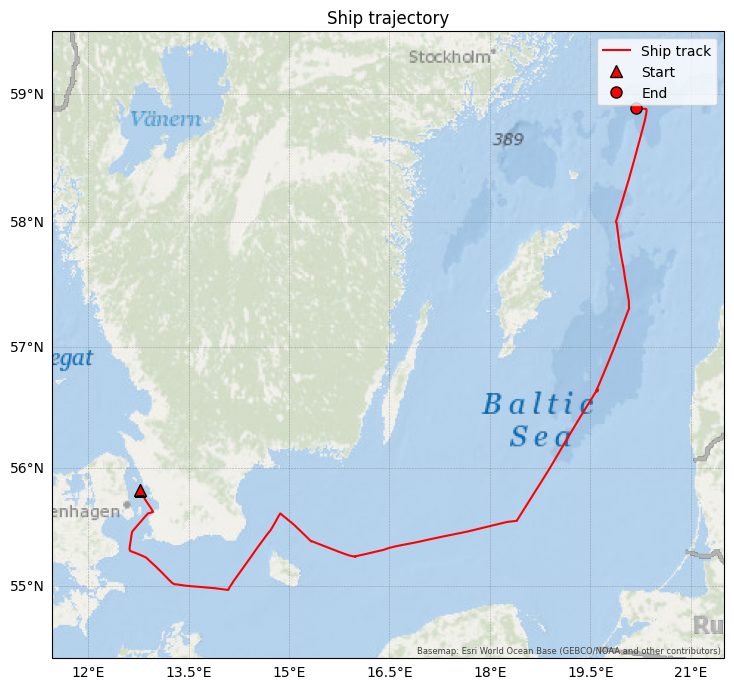

In [ ]:
# Positions already marked invalid by the VmDas PSN Valid flag
# are NaN in the reader.
valid_pos = np.isfinite(adcp.longitude) & np.isfinite(adcp.latitude)

# Additional plausibility screen for obvious navigation jumps.
# This affects only the trajectory map, not the SADCP velocity QC.
max_track_speed = 15.0 * 0.514444  # 15 knots = 7.72 m/s

def haversine_distance_m(lat1, lon1, lat2, lon2):
    earth_radius = 6371000.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dp = np.deg2rad(lat2 - lat1)
    dl = np.deg2rad(lon2 - lon1)
    a = (
        np.sin(dp / 2.0)**2
        + np.cos(p1) * np.cos(p2) * np.sin(dl / 2.0)**2
    )
    return 2.0 * earth_radius * np.arcsin(np.sqrt(a))

track_ok = np.zeros(len(adcp.ensemble), dtype=bool)
last_ok = None

time_seconds = (
    adcp.time_instrument.astype("datetime64[ms]").astype(np.int64) / 1000.0
)

for i in range(len(adcp.ensemble)):
    if not valid_pos[i]:
        continue

    if last_ok is None:
        track_ok[i] = True
        last_ok = i
        continue

    dt = time_seconds[i] - time_seconds[last_ok]
    if dt <= 0:
        continue

    distance = haversine_distance_m(
        adcp.latitude[last_ok],
        adcp.longitude[last_ok],
        adcp.latitude[i],
        adcp.longitude[i],
    )
    implied_speed = distance / dt

    if implied_speed <= max_track_speed:
        track_ok[i] = True
        last_ok = i

print(f"VmDas-valid positions: {valid_pos.sum()} / {len(valid_pos)}")
print(
    "Additional position jumps rejected by track screen: "
    f"{valid_pos.sum() - track_ok.sum()}"
)

if np.sum(track_ok) < 2:
    print("Not enough valid navigation positions to draw a ship track.")

else:
    lon_track = adcp.longitude[track_ok]
    lat_track = adcp.latitude[track_ok]

    lon_span = np.nanmax(lon_track) - np.nanmin(lon_track)
    lat_span = np.nanmax(lat_track) - np.nanmin(lat_track)

    lon_pad = max(0.05, lon_span * 0.15)
    lat_pad = max(0.03, lat_span * 0.15)

    map_extent = [
        np.nanmin(lon_track) - lon_pad,
        np.nanmax(lon_track) + lon_pad,
        np.nanmin(lat_track) - lat_pad,
        np.nanmax(lat_track) + lat_pad,
    ]

    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        import cartopy.io.img_tiles as cimgt

        have_cartopy = True
    except ImportError:
        have_cartopy = False

    if have_cartopy:
        # Esri World Ocean Base uses the standard Web-Mercator XYZ tile scheme.
        class EsriOceanTiles(cimgt.GoogleTiles):
            def _image_url(self, tile):
                x, y, z = tile
                return (
                    "https://server.arcgisonline.com/arcgis/rest/services/"
                    f"Ocean/World_Ocean_Base/MapServer/tile/{z}/{y}/{x}"
                )

        class EsriOceanReference(cimgt.GoogleTiles):
            def __init__(self):
                # The reference layer is a transparent PNG. RGBA is required;
                # converting it to RGB turns transparent pixels black and hides
                # the bathymetric base layer.
                super().__init__(desired_tile_form="RGBA")

            def _image_url(self, tile):
                x, y, z = tile
                return (
                    "https://server.arcgisonline.com/arcgis/rest/services/"
                    f"Ocean/World_Ocean_Reference/MapServer/tile/{z}/{y}/{x}"
                )

        # Select a sensible tile zoom from the geographic width of the track.
        map_span = max(lon_span, lat_span)
        if map_span > 4.0:
            tile_zoom = 6
        elif map_span > 2.0:
            tile_zoom = 7
        elif map_span > 1.0:
            tile_zoom = 8
        elif map_span > 0.5:
            tile_zoom = 9
        else:
            tile_zoom = 10

        # Create the Esri tile objects first so the map axes can use
        # the native Web-Mercator tile projection. This avoids horizontal
        # distortion at high latitudes.
        ocean_tiles = EsriOceanTiles()
        ocean_reference = EsriOceanReference()

        fig = plt.figure(figsize=(8, 7))
        ax = plt.axes(projection=ocean_tiles.crs)
        ax.set_extent(map_extent, crs=ccrs.PlateCarree())

        # Try the Esri marine/bathymetric basemap first.
        use_esri_tiles = True
        try:
            ax.add_image(ocean_tiles, tile_zoom, zorder=0)
            ax.add_image(ocean_reference, tile_zoom, zorder=1)
        except Exception as exc:
            use_esri_tiles = False
            print("Esri Ocean basemap could not be initialized:", exc)

        # Fallback background if tiles are unavailable.
        # This is also useful while the web tiles are loading.
        if not use_esri_tiles:
            ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=0)
            ax.add_feature(cfeature.OCEAN, facecolor="0.97", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)
            ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":", zorder=1)

        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.4,
            color="0.4",
            alpha=0.5,
            linestyle="--",
            zorder=2,
        )
        gl.top_labels = False
        gl.right_labels = False

        transform = ccrs.PlateCarree()

    else:
        print(
            "Cartopy is not installed. Drawing the trajectory without a basemap."
        )
        fig, ax = plt.subplots(figsize=(8, 7))
        ax.set_xlim(map_extent[0], map_extent[1])
        ax.set_ylim(map_extent[2], map_extent[3])
        ax.set_xlabel("Longitude (°E)")
        ax.set_ylabel("Latitude (°N)")
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
        transform = None

    plot_kwargs = {}
    if transform is not None:
        plot_kwargs["transform"] = transform

    ax.plot(
        lon_track,
        lat_track,
        color="red",
        linewidth=1.5,
        label="Ship track",
        zorder=4,
        **plot_kwargs,
    )

    ax.plot(
        lon_track[0],
        lat_track[0],
        marker="^",
        markersize=9,
        markerfacecolor="red",
        markeredgecolor="black",
        linestyle="None",
        label="Start",
        zorder=5,
        **plot_kwargs,
    )

    ax.plot(
        lon_track[-1],
        lat_track[-1],
        marker="o",
        markersize=8,
        markerfacecolor="red",
        markeredgecolor="black",
        linestyle="None",
        label="End",
        zorder=5,
        **plot_kwargs,
    )

    ax.set_title("Ship trajectory")
    ax.legend(loc="best")

    # Esri/data attribution for the web basemap.
    if have_cartopy and use_esri_tiles:
        ax.text(
            0.995,
            0.005,
            "Basemap: Esri World Ocean Base (GEBCO/NOAA and other contributors)",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=6,
            color="0.25",
            zorder=6,
        )

    fig.tight_layout()

    if save_plots:
        map_file = STA_FILE.with_name(f"{STA_FILE.stem}_track.jpg")
        fig.savefig(map_file, dpi=jpg_dpi, bbox_inches="tight")
        print(f"Saved: {map_file}")

    plt.show()


## 9. Look at the array sizes

Velocity arrays are **time × depth cell**. Correlation, echo intensity, and percent good are **time × depth cell × 4 beams/fields**.


In [ ]:
print("u:", adcp.u.shape)
print("v:", adcp.v.shape)
print("w:", adcp.w.shape)
print("error velocity:", adcp.error_velocity.shape)
print("correlation:", adcp.correlation.shape)
print("echo:", adcp.echo.shape)
print("percent good:", adcp.percent_good.shape)
print("bottom-track range:", adcp.bt_range.shape)
print("latitude:", adcp.latitude.shape)
print("longitude:", adcp.longitude.shape)


u: (3329, 58)
v: (3329, 58)
w: (3329, 58)
error velocity: (3329, 58)
correlation: (3329, 58, 4)
echo: (3329, 58, 4)
percent good: (3329, 58, 4)
bottom-track range: (3329, 4)
latitude: (3329,)
longitude: (3329,)


## 10. Plot the selected main velocity parameters directly from the STA file

Plot the `main_velocity_parameters = "uv"` for eastward/northward velocity, or `"magdir"` for magnitude/direction chosen in 2. User settings. These are calculated directly from the STA-file `u` and `v` values; no navigation/ship-speed correction is added here.


Saved: ADCPOS150_77SE_2026_19_004_000000_u_raw.jpg


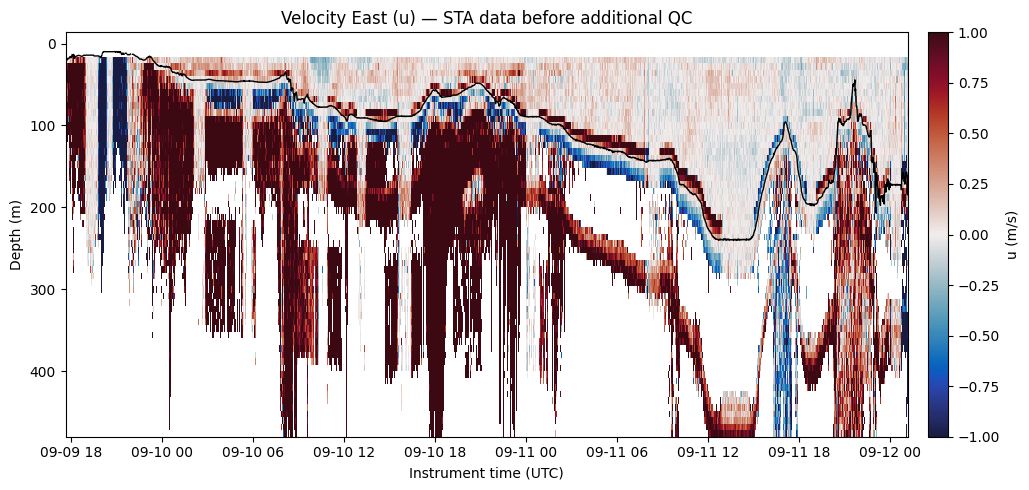

Saved: ADCPOS150_77SE_2026_19_004_000000_v_raw.jpg


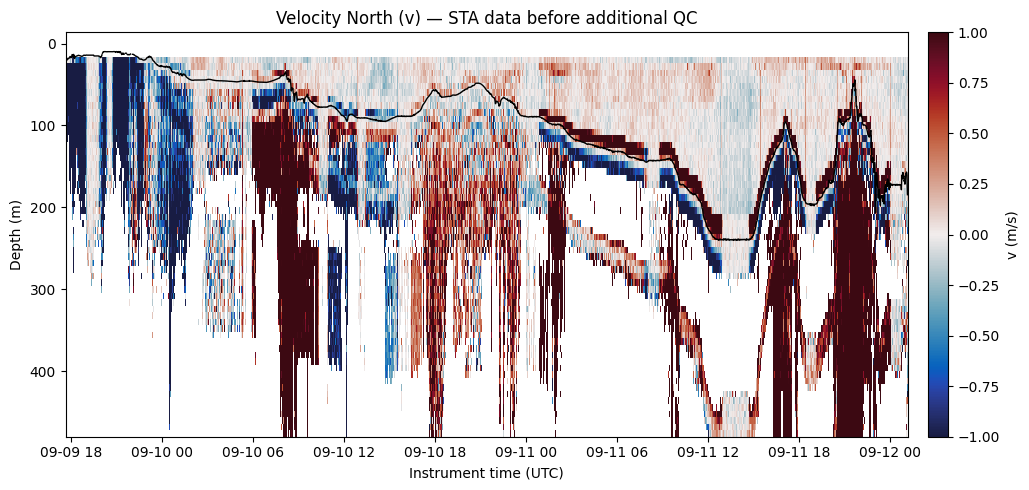

In [ ]:
# Main velocity variables before additional QC
magnitude = np.hypot(adcp.u, adcp.v)
direction = (np.degrees(np.arctan2(adcp.u, adcp.v)) + 360.0) % 360.0

# Mean bottom-track depth, plotted like the bottom line in WinADCP.
has_bt_plot = np.isfinite(adcp.bt_range).any(axis=1)
bt_depth_plot = np.full(len(adcp.ensemble), np.nan)
bt_depth_plot[has_bt_plot] = (
    np.nanmean(adcp.bt_range[has_bt_plot], axis=1) + transducer_depth
)

def plot_main_field(data, title, cmap, vmin, vmax, label, suffix):
    fig, ax = plt.subplots(figsize=(11, 5))
    pcm = ax.pcolormesh(adcp.time_instrument, depth, data.T, shading="auto",
                        cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel("Instrument time (UTC)")
    ax.set_ylabel("Depth (m)")
    ax.set_title(title)
    ax.plot(adcp.time_instrument, bt_depth_plot, color="black", linewidth=1.0, label="BT depth")
    cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
    cbar.set_label(label)
    finish_plot(fig, ax, suffix)

if main_velocity_parameters == "uv":
    plot_main_field(adcp.u, "Velocity East (u) — STA data before additional QC",
                    cmocean.cm.balance, -velocity_limit, velocity_limit, "u (m/s)", "_u_raw")
    plot_main_field(adcp.v, "Velocity North (v) — STA data before additional QC",
                    cmocean.cm.balance, -velocity_limit, velocity_limit, "v (m/s)", "_v_raw")
elif main_velocity_parameters == "magdir":
    plot_main_field(magnitude, "Current magnitude — STA data before additional QC",
                    cmocean.cm.tempo, 0, velocity_limit, "Magnitude (m/s)", "_mag_raw")
    plot_main_field(direction, "Current direction — STA data before additional QC",
                    cmocean.cm.phase, 0, 360, "Direction toward (degrees)", "_dir_raw")
else:
    raise ValueError('main_velocity_parameters must be "uv" or "magdir"')


# Quality control

The following tests are deliberately kept separate. This makes it possible to see why a measurement is rejected rather than applying an opaque combined filter.

**All automatic QC tests in this notebook are binary: a cell either passes (accepted) or fails (rejected). No "suspect" class is used.**

For this implementation we use:

- correlation: **accepted** when at least 3 of 4 beams reach the selected limit (64 counts for WH600, 110 counts for OS150); otherwise **rejected**,
- error velocity: **accepted** when `|error velocity| ≤ 0.15 m/s`; otherwise **rejected**,
- percent good: **accepted** when `PG1 + PG4 > 10%`; otherwise **rejected**,
- bottom/sidelobe: **accepted** above the selected Cos(BeamAngle) bottom limit; otherwise **rejected** where bottom track is available.

These parameters are stored in the STA file. They do not alter or re-reference the velocity before testing it.


## 11. QC test 1 — correlation

For each time/depth cell we count how many of the four beams reach the selected correlation limit.

The default depends on the instrument:

- **WH600:** at least 3 of 4 beams with correlation ≥ **64** counts
- **OS150:** at least 3 of 4 beams with correlation ≥ **110** counts


In [ ]:
good_corr_beam = adcp.correlation >= corr_limit
n_good_corr_beams = np.sum(good_corr_beam, axis=2)

good_corr = n_good_corr_beams >= min_good_corr_beams

print(f"Correlation limit: {corr_limit} counts")
print(f"Accepted: at least {min_good_corr_beams} of 4 beams")
print(f"Rejected: fewer than {min_good_corr_beams} of 4 beams")


Correlation limit: 110 counts
Accepted: at least 3 of 4 beams
Rejected: fewer than 3 of 4 beams


Saved: ADCPOS150_77SE_2026_19_004_000000_corr.jpg


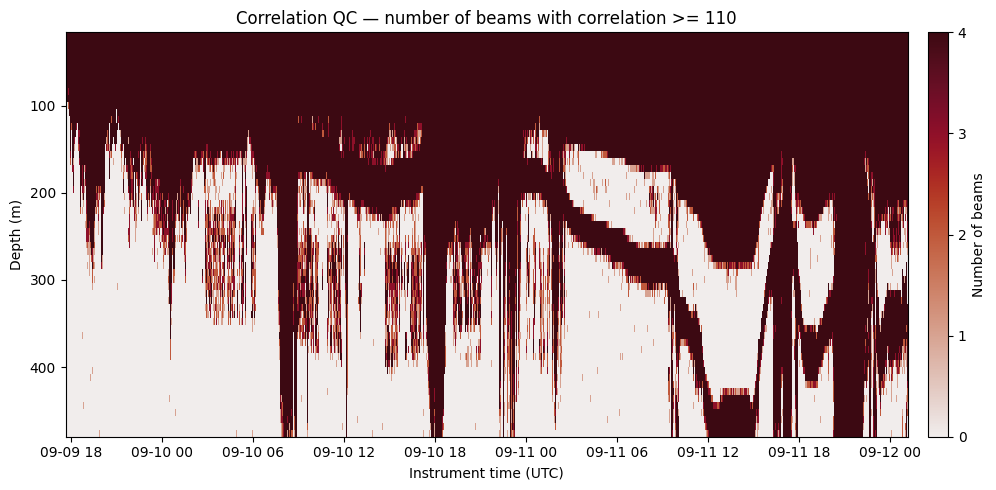

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

pcm = ax.pcolormesh(
    adcp.time_instrument,
    depth,
    n_good_corr_beams.T,
    shading="auto",
    cmap=cmocean.cm.amp,
    vmin=0,
    vmax=4,
)

ax.set_xlabel("Instrument time (UTC)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"Correlation QC — number of beams with correlation >= {corr_limit}")

cbar = plt.colorbar(pcm, ax=ax, pad=0.02, ticks=[0, 1, 2, 3, 4])
cbar.set_label("Number of beams")

finish_plot(fig, ax, "_corr")


## 12. QC test 2 — error velocity

Error velocity is useful because disagreement between the four beams produces a large error-velocity value. The same binary QC limit is used for WH600 and OS150:

- **accepted:** `|error velocity| ≤ 0.15 m/s`
- **rejected:** `|error velocity| > 0.15 m/s`

There is **no suspect class** in the QC. The error-velocity plot is displayed to ±0.30 m/s only to make the structure easy to inspect; ±0.30 m/s is a plotting limit, not a second QC threshold.


In [ ]:
abs_err = np.abs(adcp.error_velocity)

# Binary QC: True = accepted, False = rejected.
good_error = abs_err <= error_velocity_good

print(f"Accepted: |error velocity| <= {error_velocity_good:.2f} m/s")
print(f"Rejected: |error velocity| >  {error_velocity_good:.2f} m/s")


Accepted: |error velocity| <= 0.15 m/s
Rejected: |error velocity| >  0.15 m/s


Saved: ADCPOS150_77SE_2026_19_004_000000_errvel.jpg


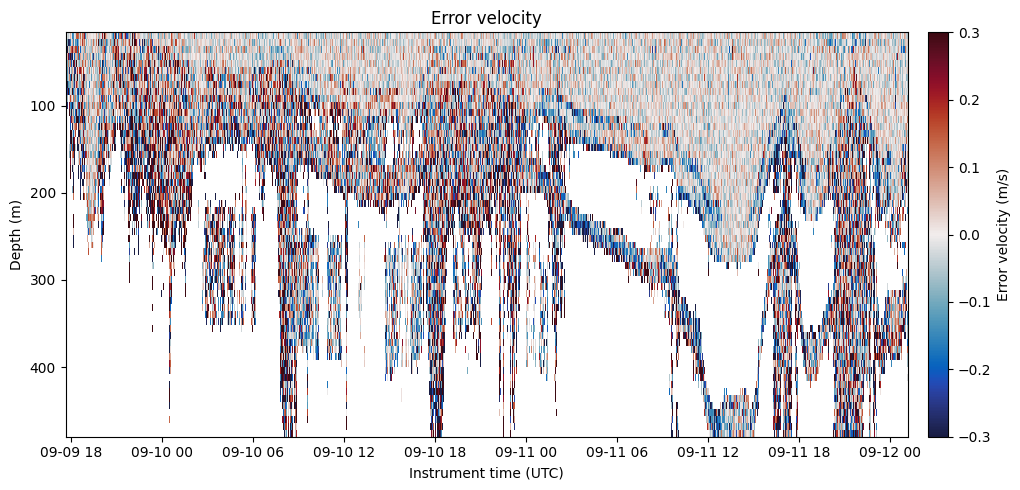

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

pcm = ax.pcolormesh(
    adcp.time_instrument,
    depth,
    adcp.error_velocity.T,
    shading="auto",
    cmap=cmocean.cm.balance,
    vmin=-error_velocity_plot_limit,
    vmax=error_velocity_plot_limit,
)

ax.set_xlabel("Instrument time (UTC)")
ax.set_ylabel("Depth (m)")
ax.set_title("Error velocity")

cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("Error velocity (m/s)")

finish_plot(fig, ax, "_errvel")


## 13. QC test 3 — percent good

For the four percent-good fields used here:

- **PG1** is the fraction of 3-beam solutions,
- **PG4** is the fraction of 4-beam solutions.

The binary QC criterion for both instruments is:

- **accepted:** `PG1 + PG4 > 10%`
- **rejected:** `PG1 + PG4 ≤ 10%`


In [ ]:
pg1 = adcp.percent_good[:, :, 0].astype(float)
pg4 = adcp.percent_good[:, :, 3].astype(float)
pg14 = pg1 + pg4

good_pg = pg14 > percent_good_limit

print(f"Accepted: PG1 + PG4 > {percent_good_limit}%")
print(f"Rejected: PG1 + PG4 <= {percent_good_limit}%")


Accepted: PG1 + PG4 > 10%
Rejected: PG1 + PG4 <= 10%


Saved: ADCPOS150_77SE_2026_19_004_000000_pg.jpg


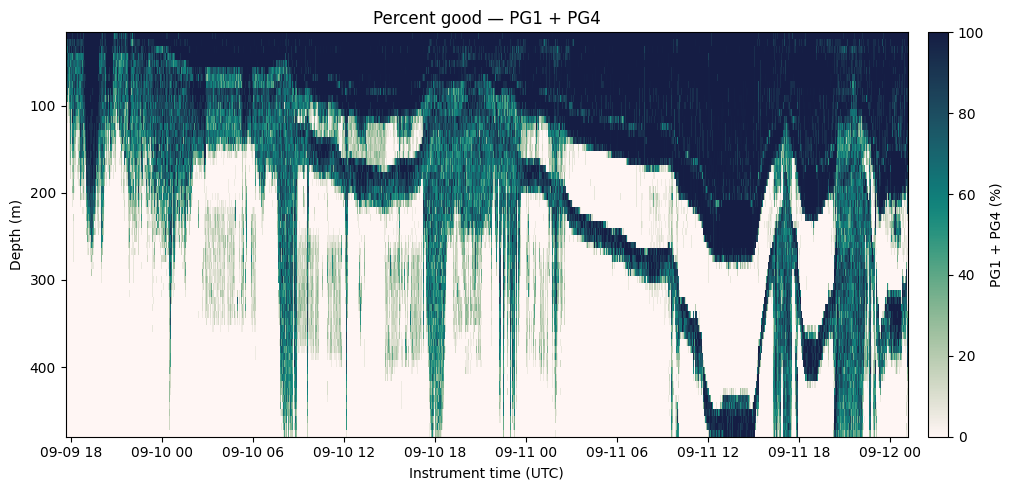

In [ ]:


fig, ax = plt.subplots(figsize=(11, 5))

pcm = ax.pcolormesh(
    adcp.time_instrument,
    depth,
    pg14.T,
    shading="auto",
    cmap=cmocean.cm.tempo,
    vmin=0,
    vmax=100,
)

ax.set_xlabel("Instrument time (UTC)")
ax.set_ylabel("Depth (m)")
ax.set_title("Percent good — PG1 + PG4")

cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("PG1 + PG4 (%)")

finish_plot(fig, ax, "_pg")


## 14. Echo intensity — visual diagnostic

Echo intensity is not given a fixed rejection threshold here. Instead, inspect whether the four beams behave similarly, whether signal decreases with range, and whether there is a strong bottom return.

The first plot below shows the mean of the four beams.


Saved: ADCPOS150_77SE_2026_19_004_000000_echo.jpg


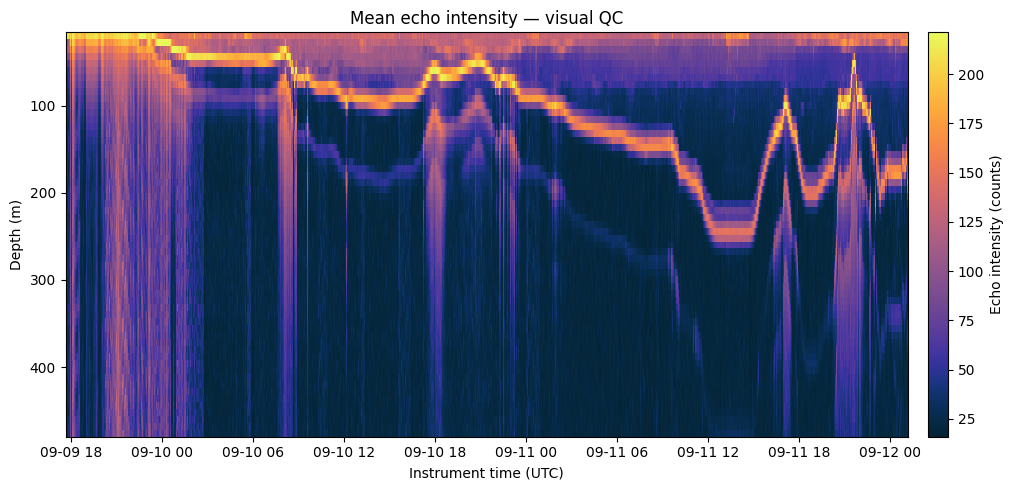

In [ ]:
echo_mean = adcp.echo.mean(axis=2)
echo_spread = adcp.echo.max(axis=2) - adcp.echo.min(axis=2)

fig, ax = plt.subplots(figsize=(11, 5))

pcm = ax.pcolormesh(
    adcp.time_instrument,
    depth,
    echo_mean.T,
    shading="auto",
    cmap=cmocean.cm.thermal,
)

ax.set_xlabel("Instrument time (UTC)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mean echo intensity — visual QC")

cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("Echo intensity (counts)")

finish_plot(fig, ax, "_echo")


## 15. QC test 4 — bottom/sidelobe limit: Cos(BeamAngle)

Near the bottom, sidelobe returns can contaminate the water-velocity estimate. The STA file contains four **bottom-track vertical ranges**, one for each beam.

For plotting the bottom, we use the **mean of the valid four bottom-track beam ranges** and add the user-entered transducer depth:

`BT depth = transducer depth + mean(bottom-track beam ranges)`

For sidelobe QC, we use the **shallowest valid bottom-track beam** and the instrument beam angle:

`geometric sidelobe boundary = shallowest bottom-track range × cos(beam angle)`

The boundary must always be **shallower than the measured bottom**.

A water-profile value represents a complete depth cell, not only its centre. Therefore a cell is accepted only if its **far/deep edge** is above the geometric sidelobe boundary:

`cell centre range + 0.5 × cell size <= sidelobe boundary`

This is deliberately conservative near the bottom and avoids retaining a cell whose centre is above the boundary but whose lower half overlaps the sidelobe-contaminated zone.

### Optional extra bottom bin

The geometric `Cos(BeamAngle)` limit does not always remove every visibly contaminated near-bottom cell. Real bottom returns have finite width, and residual sidelobe interference can sometimes remain in the last accepted depth cell. This can appear as an isolated, unrealistically large velocity immediately above the bottom.

The user setting `extra_bottom_bins` provides a simple conservative option:

- `extra_bottom_bins = 0` — use the normal Cos(BeamAngle) test only.
- `extra_bottom_bins = 1` — also reject one additional depth cell above the normal limit.

Start with `0`. Use `1` if visual inspection of velocity and echo intensity indicates that Cos(BeamAngle) alone is not sufficient. The setting is applied in exactly the same way for WH600 and OS150. The dashed line in the plots still shows the geometric Cos(BeamAngle) boundary; it is not moved when an extra bin is rejected.

The plotted dashed line is the geometric sidelobe boundary. Both the BT-depth line and the sidelobe line include the user-entered `transducer_depth`.

Important: Cos(BeamAngle) can only be calculated where bottom-track range exists. If bottom track is missing, this bottom test is left neutral rather than rejecting the whole profile.


In [ ]:
beam_angle = adcp.config["beam_angle_deg"]
cell_size = adcp.config["cell_size_m"]

# Bottom track available?
has_bt = np.isfinite(adcp.bt_range).any(axis=1)

# Mean BT range is used only for plotting the bottom line.
bt_range_mean = np.full(len(adcp.ensemble), np.nan)
bt_range_mean[has_bt] = np.nanmean(adcp.bt_range[has_bt], axis=1)

# Sidelobe QC uses the shallowest valid BT beam.
bt_range_shallowest = np.full(len(adcp.ensemble), np.nan)
bt_range_shallowest[has_bt] = np.nanmin(adcp.bt_range[has_bt], axis=1)

# Geometric sidelobe boundary from the transducer.
# This must be shallower than the bottom itself.
sidelobe_limit_range = (
    bt_range_shallowest * np.cos(np.deg2rad(beam_angle))
)

# A depth cell has finite thickness. Reject a cell if its deep/far edge
# extends below the sidelobe boundary.
cell_far_edge = adcp.range_m + 0.5 * cell_size

# Convert lines to depth below sea surface for plotting.
bt_depth = bt_range_mean + transducer_depth
sidelobe_limit_depth = sidelobe_limit_range + transducer_depth

# Optional conservative margin: remove extra complete depth cells above
# the geometric Cos(BeamAngle) boundary. The plotted dashed line remains
# the geometric boundary; only the QC acceptance limit is shifted upward.
bottom_qc_limit_range = sidelobe_limit_range - extra_bottom_bins * cell_size

# If BT is unavailable, do not reject data on this test alone.
good_bottom = np.ones_like(adcp.u, dtype=bool)
good_bottom[has_bt] = (
    cell_far_edge[None, :] <= bottom_qc_limit_range[has_bt, None]
)

print(f"Beam angle: {beam_angle:.1f} degrees")
print(f"Cell size:  {cell_size:.2f} m")
print(f"Extra bottom bins removed: {extra_bottom_bins}")
print(f"Bottom-track available: {has_bt.sum()} / {len(has_bt)} ensembles")
print(f"Bottom-track missing:   {(~has_bt).sum()} / {len(has_bt)} ensembles")

# Sanity checks.
# 1. The geometric sidelobe boundary must never be deeper than the
#    shallowest bottom-track range.
boundary_problem = np.sum(
    has_bt & (sidelobe_limit_range >= bt_range_shallowest)
)

# 2. Where BT exists, no accepted cell may have its far edge below
#    the sidelobe boundary.
below_limit = (
    cell_far_edge[None, :] > bottom_qc_limit_range[:, None]
)
violations = np.sum(
    good_bottom & below_limit & has_bt[:, None]
)

print(f"Sidelobe boundary at/below BT: {boundary_problem}")
print(f"Accepted cells crossing bottom QC limit: {violations}")


Beam angle: 30.0 degrees
Cell size:  8.00 m
Extra bottom bins removed: 0
Bottom-track available: 3314 / 3329 ensembles
Bottom-track missing:   15 / 3329 ensembles
Sidelobe boundary at/below BT: 0
Accepted cells crossing bottom QC limit: 0


Saved: ADCPOS150_77SE_2026_19_004_000000_u_bottom.jpg


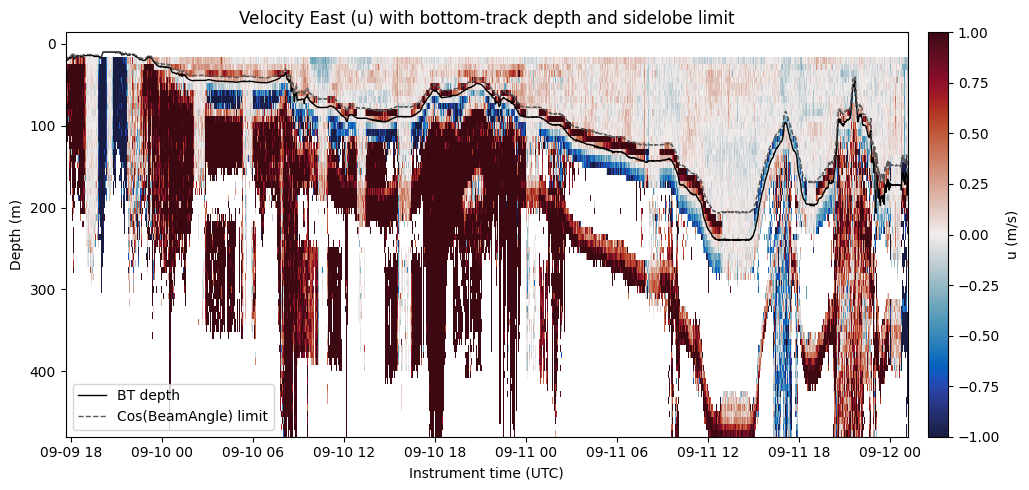

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

if main_velocity_parameters == "uv":
    bottom_plot_data = adcp.u
    bottom_plot_cmap = cmocean.cm.balance
    bottom_plot_vmin, bottom_plot_vmax = -velocity_limit, velocity_limit
    bottom_plot_title = "Velocity East (u) with bottom-track depth and sidelobe limit"
    bottom_plot_label = "u (m/s)"
    bottom_plot_suffix = "_u_bottom"
else:
    bottom_plot_data = magnitude
    bottom_plot_cmap = cmocean.cm.tempo
    bottom_plot_vmin, bottom_plot_vmax = 0, velocity_limit
    bottom_plot_title = "Current magnitude with bottom-track depth and sidelobe limit"
    bottom_plot_label = "Magnitude (m/s)"
    bottom_plot_suffix = "_mag_bottom"

pcm = ax.pcolormesh(
    adcp.time_instrument, depth, bottom_plot_data.T, shading="auto",
    cmap=bottom_plot_cmap, vmin=bottom_plot_vmin, vmax=bottom_plot_vmax,
)

# Solid black: mean BT depth.
ax.plot(
    adcp.time_instrument,
    bt_depth,
    color="black",
    linewidth=1.0,
    label="BT depth",
)

# Dashed grey: geometric Cos(BeamAngle) sidelobe boundary.
ax.plot(
    adcp.time_instrument,
    sidelobe_limit_depth,
    color="0.35",
    linewidth=1.0,
    linestyle="--",
    label="Cos(BeamAngle) limit",
)

ax.set_xlabel("Instrument time (UTC)")
ax.set_ylabel("Depth (m)")
ax.set_title(bottom_plot_title)
ax.legend(loc="lower left")

cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label(bottom_plot_label)

finish_plot(fig, ax, bottom_plot_suffix)


## 16. Combine the four automatic QC tests

Only cells that pass **all four** tests are accepted in this QC mask:

1. correlation,
2. error velocity,
3. percent good, and
4. Cos(BeamAngle) bottom/sidelobe limit where bottom track is available.


In [ ]:
velocity_present = np.isfinite(adcp.u) & np.isfinite(adcp.v)

good_qc = velocity_present & good_corr & good_error & good_pg & good_bottom

n_present = np.count_nonzero(velocity_present)
n_good = np.count_nonzero(good_qc)

print(f"Velocity cells with data:       {n_present:d}")
print(f"Cells retained after all QC:    {n_good:d}")
if n_present > 0:
    print(f"Cells retained:                 {100*n_good/n_present:.1f} %")

print("\nData-quality tests:")
for name, test in [
    ("Correlation acceptable", good_corr),
    ("Error velocity acceptable", good_error),
    ("Percent good acceptable", good_pg),
]:
    n = np.count_nonzero(velocity_present & test)
    print(f"  {name:27s}: {100*n/n_present:5.1f} %")

print("\nBottom and sidelobe screening:")
n = np.count_nonzero(velocity_present & good_bottom)
print(f"  {'Cells above seafloor sidelobe limit':27s}: {100*n/n_present:5.1f} %")

print(
    "\nNote: The bottom and sidelobe screening is a depth limitation rather than a\n"
    "measurement-quality test. It removes cells that are below or too close to\n"
    "the bottom, where sidelobe interference may contaminate the measurements."
)

Velocity cells with data:       116547
Cells retained after all QC:    27089
Cells retained:                 23.2 %

Data-quality tests:
  Correlation acceptable     :  90.7 %
  Error velocity acceptable  :  67.2 %
  Percent good acceptable    :  93.2 %

Bottom and sidelobe screening:
  Cells above seafloor sidelobe limit:  23.7 %

Note: The bottom and sidelobe screening is a depth limitation rather than a
measurement-quality test. It removes cells that are below or too close to
the bottom, where sidelobe interference may contaminate the measurements.


Saved: ADCPOS150_77SE_2026_19_004_000000_qcmask.jpg


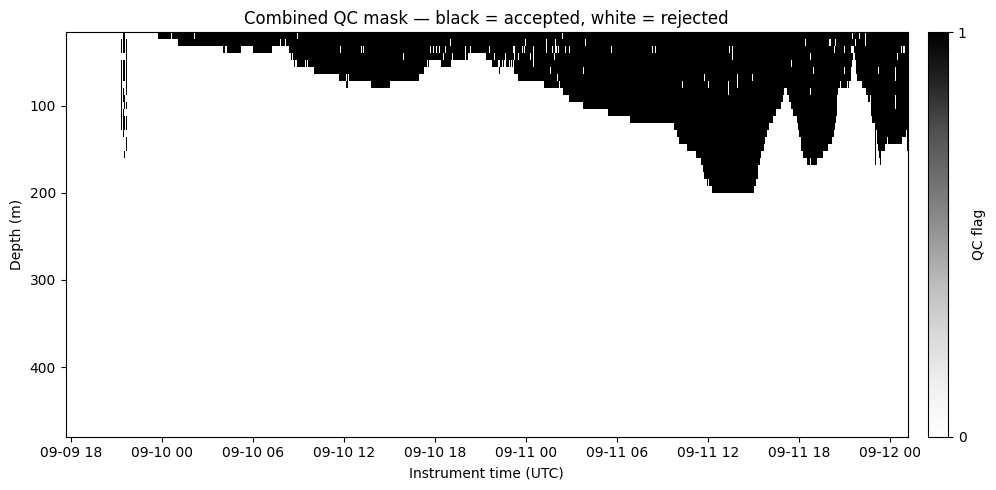

In [ ]:
# Show the combined mask: 1 = accepted, 0 = rejected
fig, ax = plt.subplots(figsize=(11, 5))

pcm = ax.pcolormesh(
    adcp.time_instrument,
    depth,
    good_qc.T.astype(int),
    shading="auto",
    cmap="Greys",
    vmin=0,
    vmax=1,
)

ax.set_xlabel("Instrument time (UTC)")
ax.set_ylabel("Depth (m)")
ax.set_title("Combined QC mask — black = accepted, white = rejected")

cbar = plt.colorbar(pcm, ax=ax, pad=0.02, ticks=[0, 1])
cbar.set_label("QC flag")

finish_plot(fig, ax, "_qcmask")


## 17. Apply the QC mask and plot the selected main velocity parameters

The raw data are not changed. Rejected cells are replaced by `NaN` only in the QC copies used for plotting/analysis.


Saved: ADCPOS150_77SE_2026_19_004_000000_u.jpg


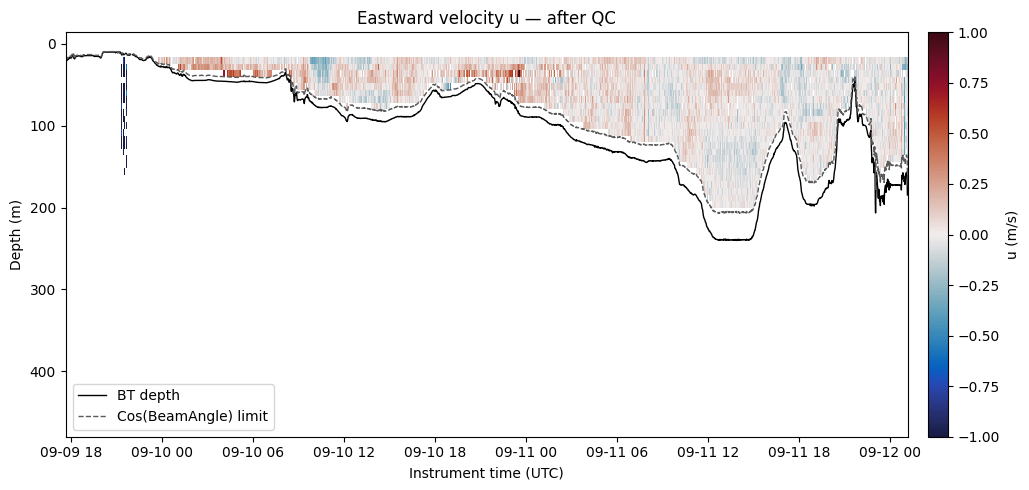

Saved: ADCPOS150_77SE_2026_19_004_000000_v.jpg


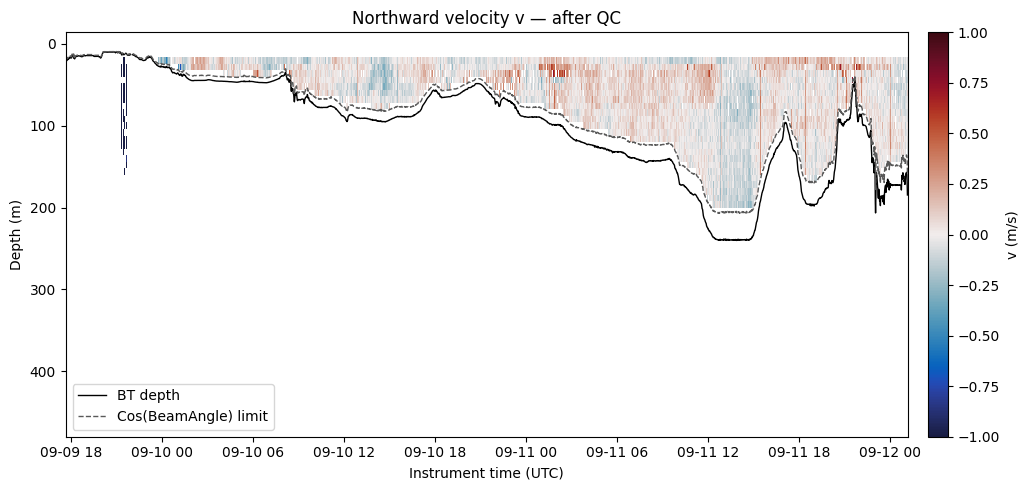

In [ ]:
# Recalculate all derived velocity variables here so this cell works
# even if the earlier raw-plot cell has not been run in the current kernel.
magnitude = np.hypot(adcp.u, adcp.v)
direction = (np.degrees(np.arctan2(adcp.u, adcp.v)) + 360.0) % 360.0

u_qc = np.where(good_qc, adcp.u, np.nan)
v_qc = np.where(good_qc, adcp.v, np.nan)
magnitude_qc = np.where(good_qc, magnitude, np.nan)
direction_qc = np.where(good_qc, direction, np.nan)

def plot_qc_field(data, title, cmap, vmin, vmax, label, suffix):
    fig, ax = plt.subplots(figsize=(11, 5))
    pcm = ax.pcolormesh(adcp.time_instrument, depth, data.T, shading="auto",
                        cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel("Instrument time (UTC)")
    ax.set_ylabel("Depth (m)")
    ax.set_title(title)
    ax.plot(adcp.time_instrument, bt_depth, color="black", linewidth=1.0, label="BT depth")
    ax.plot(adcp.time_instrument, sidelobe_limit_depth, color="0.35", linewidth=1.0,
            linestyle="--", label="Cos(BeamAngle) limit")
    ax.legend(loc="lower left")
    cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
    cbar.set_label(label)
    finish_plot(fig, ax, suffix)

if main_velocity_parameters == "uv":
    plot_qc_field(u_qc, "Eastward velocity u — after QC", cmocean.cm.balance,
                  -velocity_limit, velocity_limit, "u (m/s)", "_u")
    plot_qc_field(v_qc, "Northward velocity v — after QC", cmocean.cm.balance,
                  -velocity_limit, velocity_limit, "v (m/s)", "_v")
else:
    plot_qc_field(magnitude_qc, "Current magnitude — after QC", cmocean.cm.tempo,
                  0, velocity_limit, "Magnitude (m/s)", "_mag")
    plot_qc_field(direction_qc, "Current direction — after QC", cmocean.cm.phase,
                  0, 360, "Direction toward (degrees)", "_dir")


## 18. Export the QC'd current data

If `export_qc_data = True` in the User Settings, the notebook writes the cleaned current data in the selected format.

The main exported parameters are:

- **time** — ADCP instrument time (UTC)
- **longitude**
- **latitude**
- **depth**
- **u** — eastward velocity
- **v** — northward velocity

The representative latitude/longitude for each STA ensemble is the **last valid VmDas navigation fix** in that averaged ensemble, matching the VmDas ship-track convention. If the PSN Valid flag is false, latitude/longitude are left missing.

### CSV

CSV is the simplest option for users who want to open the result in Excel or another general program. The complete original **time × depth grid** is preserved. If a velocity cell fails QC, its `u` and `v` values are written as `NaN`. This keeps genuine time gaps distinguishable from QC rejection.

CSV timestamps use the **ADCP instrument time (UTC)** and are rounded to the nearest whole second.

### NetCDF

NetCDF keeps the natural **time × depth** structure of the SADCP data. Measurements that failed QC are stored as missing values; no per-test QC flags or rejection reasons are written.

The NetCDF also contains available instrument/navigation metadata from the STA reader, including instrument configuration, heading/pitch/roll, temperature, salinity, sound speed, bottom-track ranges, navigation positions/times, Speed Made Good components, source filename, transducer depth, and the processing/QC settings used in this notebook.

All NetCDF time variables are stored as **decimal days since 1 January of the measurement year**, using the same reference year for `time`, `instrument_time`, `first_navigation_time`, and `last_navigation_time`.


In [ ]:

if export_qc_data:
    # Main exported time = ADCP instrument RTC (UTC).
    # This is the same time used on the velocity plots.
    export_time = adcp.time_instrument.copy()

    if export_format.lower() == "csv":
        import csv

        output_file = STA_FILE.with_name(f"{STA_FILE.stem}_QC.csv")

        # Round instrument timestamps to the nearest whole second.
        export_time_rounded = (
            export_time.astype("datetime64[ms]")
            + np.timedelta64(500, "ms")
        ).astype("datetime64[s]")

        n_total_rows = 0
        n_accepted = 0
        n_rejected = 0

        with open(output_file, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "time_utc",
                "longitude_deg_east",
                "latitude_deg_north",
                "depth_m",
                "u_ms",
                "v_ms",
            ])

            # Preserve the complete original time x depth grid.
            # QC-rejected velocities are written as NaN rather than omitted.
            for it in range(len(adcp.ensemble)):
                time_string = str(export_time_rounded[it]).replace("T", " ")

                lon = (
                    f"{adcp.longitude[it]:.8f}"
                    if np.isfinite(adcp.longitude[it])
                    else "NaN"
                )
                lat = (
                    f"{adcp.latitude[it]:.8f}"
                    if np.isfinite(adcp.latitude[it])
                    else "NaN"
                )

                for iz in range(len(depth)):
                    accepted = (
                        good_qc[it, iz]
                        and np.isfinite(adcp.u[it, iz])
                        and np.isfinite(adcp.v[it, iz])
                    )

                    if accepted:
                        u_out = f"{adcp.u[it, iz]:.6f}"
                        v_out = f"{adcp.v[it, iz]:.6f}"
                        n_accepted += 1
                    else:
                        u_out = "NaN"
                        v_out = "NaN"
                        n_rejected += 1

                    writer.writerow([
                        time_string,
                        lon,
                        lat,
                        f"{depth[iz]:.3f}",
                        u_out,
                        v_out,
                    ])
                    n_total_rows += 1

        print(f"QC data exported: {output_file}")
        print(f"Rows written:               {n_total_rows:d}")
        print(f"Accepted velocity cells:    {n_accepted:d}")
        print(f"QC-rejected/missing cells:  {n_rejected:d}")

    elif export_format.lower() == "netcdf":
        try:
            import xarray as xr
        except ImportError as exc:
            raise ImportError(
                "NetCDF export requires xarray and scipy. "
                "Run the installation cell near the top of the notebook once."
            ) from exc

        output_file = STA_FILE.with_name(f"{STA_FILE.stem}_QC.nc")

        # ------------------------------------------------------------
        # NetCDF time convention
        # ------------------------------------------------------------
        # Store all times as decimal days since 1 January of the
        # measurement year, using the same reference for every time variable.
        valid_export_times = export_time[~np.isnat(export_time)]
        if len(valid_export_times) == 0:
            raise ValueError("No valid times are available for NetCDF export.")

        measurement_year = int(
            str(valid_export_times[0].astype("datetime64[Y]"))[:4]
        )
        time_origin = np.datetime64(
            f"{measurement_year:04d}-01-01T00:00:00", "ms"
        )
        time_units = f"days since {measurement_year:04d}-01-01 00:00:00"

        def datetime64_to_decimal_day(values):
            values = np.asarray(values, dtype="datetime64[ms]")
            out = np.full(values.shape, np.nan, dtype=float)
            good = ~np.isnat(values)
            out[good] = (
                (values[good] - time_origin) / np.timedelta64(1, "D")
            ).astype(float)
            return out

        time_decimal = datetime64_to_decimal_day(export_time)
        instrument_time_decimal = datetime64_to_decimal_day(adcp.time_instrument)
        first_nav_time_decimal = datetime64_to_decimal_day(
            adcp.first_time_navigation
        )
        last_nav_time_decimal = datetime64_to_decimal_day(
            adcp.last_time_navigation
        )

        common_time_attrs = {
            "units": time_units,
            "calendar": "proleptic_gregorian",
            "C_format": "%12.5f",
        }

        # Main current variables: failed QC cells are missing.
        u_export = np.where(good_qc, adcp.u, np.nan)
        v_export = np.where(good_qc, adcp.v, np.nan)

        ds = xr.Dataset(
            data_vars={
                "u": (
                    ("time", "depth"),
                    u_export,
                    {
                        "long_name": "eastward sea water velocity",
                        "units": "m s-1",
                    },
                ),
                "v": (
                    ("time", "depth"),
                    v_export,
                    {
                        "long_name": "northward sea water velocity",
                        "units": "m s-1",
                    },
                ),
                "longitude": (
                    ("time",),
                    adcp.longitude,
                    {
                        "standard_name": "longitude",
                        "units": "degrees_east",
                    },
                ),
                "latitude": (
                    ("time",),
                    adcp.latitude,
                    {
                        "standard_name": "latitude",
                        "units": "degrees_north",
                    },
                ),

                # Available time-varying metadata from the STA reader.
                "heading": (("time",), adcp.heading, {"units": "degree"}),
                "pitch": (("time",), adcp.pitch, {"units": "degree"}),
                "roll": (("time",), adcp.roll, {"units": "degree"}),
                "temperature": (("time",), adcp.temperature, {"units": "degree_C"}),
                "salinity": (("time",), adcp.salinity, {"units": "1"}),
                "speed_of_sound": (("time",), adcp.speed_of_sound, {"units": "m s-1"}),
                "instrument_transducer_depth": (
                    ("time",),
                    adcp.transducer_depth,
                    {"units": "m"},
                ),
                "speed_made_good_east": (
                    ("time",),
                    adcp.smg_east,
                    {"units": "m s-1"},
                ),
                "speed_made_good_north": (
                    ("time",),
                    adcp.smg_north,
                    {"units": "m s-1"},
                ),
                "bottom_track_range": (
                    ("time", "beam"),
                    adcp.bt_range,
                    {
                        "long_name": "bottom track vertical range from transducer",
                        "units": "m",
                    },
                ),
                "first_latitude": (
                    ("time",),
                    adcp.first_latitude,
                    {"units": "degrees_north"},
                ),
                "first_longitude": (
                    ("time",),
                    adcp.first_longitude,
                    {"units": "degrees_east"},
                ),
                "last_latitude": (
                    ("time",),
                    adcp.last_latitude,
                    {"units": "degrees_north"},
                ),
                "last_longitude": (
                    ("time",),
                    adcp.last_longitude,
                    {"units": "degrees_east"},
                ),
                "first_navigation_time": (
                    ("time",),
                    first_nav_time_decimal,
                    {
                        **common_time_attrs,
                        "long_name": "first VmDas navigation time in averaged ensemble",
                    },
                ),
                "last_navigation_time": (
                    ("time",),
                    last_nav_time_decimal,
                    {
                        **common_time_attrs,
                        "long_name": "last VmDas navigation time in averaged ensemble",
                    },
                ),
                "instrument_time": (
                    ("time",),
                    instrument_time_decimal,
                    {
                        **common_time_attrs,
                        "long_name": "ADCP instrument time",
                    },
                ),
                "navigation_flags": (
                    ("time",),
                    adcp.navigation_flags.astype(np.uint16),
                    {
                        "long_name": "VmDas binary navigation validity flags",
                    },
                ),
                "checksum_ok": (
                    ("time",),
                    adcp.checksum_ok.astype(np.int8),
                    {
                        "long_name": "PD0 ensemble checksum valid",
                        "flag_values": [0, 1],
                        "flag_meanings": "false true",
                    },
                ),
            },
            coords={
                "time": (
                    ("time",),
                    time_decimal,
                    {
                        **common_time_attrs,
                        "long_name": "Decimal day of ADCP instrument time",
                        "standard_name": "time",
                        "axis": "T",
                    },
                ),
                "depth": (
                    ("depth",),
                    depth,
                    {
                        "standard_name": "depth",
                        "long_name": "depth below sea surface",
                        "units": "m",
                        "positive": "down",
                    },
                ),
                "beam": (
                    ("beam",),
                    np.arange(1, 5, dtype=np.int16),
                ),
            },
        )

        # Add data_min/data_max metadata to all exported time variables.
        for time_name in [
            "time",
            "instrument_time",
            "first_navigation_time",
            "last_navigation_time",
        ]:
            vals = ds[time_name].values
            finite = np.isfinite(vals)
            if np.any(finite):
                ds[time_name].attrs["data_min"] = float(np.nanmin(vals))
                ds[time_name].attrs["data_max"] = float(np.nanmax(vals))

        # Global metadata from the reader configuration.
        ds.attrs["title"] = "QC'd shipboard ADCP currents from VmDas STA"
        ds.attrs["source_file"] = STA_FILE.name
        ds.attrs["instrument_selected"] = instrument
        ds.attrs["horizontal_velocity_reference"] = adcp.config.get(
            "horizontal_velocity_reference", ""
        )
        ds.attrs["user_transducer_depth_m"] = float(transducer_depth)
        ds.attrs["qc_correlation_limit_counts"] = int(corr_limit)
        ds.attrs["qc_min_good_correlation_beams"] = int(min_good_corr_beams)
        ds.attrs["qc_error_velocity_limit_ms"] = float(error_velocity_good)
        ds.attrs["qc_percent_good_limit"] = float(percent_good_limit)
        ds.attrs["qc_extra_bottom_bins"] = int(extra_bottom_bins)
        ds.attrs["qc_bottom_method"] = (
            "shallowest bottom-track range * cos(beam angle); "
            "cell far edge must be above boundary"
        )
        ds.attrs["time_slice_used"] = str(bool(use_time_slice))
        ds.attrs["failed_qc_storage"] = (
            "u and v values failing combined QC are stored as missing values; "
            "no per-test QC flags are included"
        )
        ds.attrs["main_time_source"] = "ADCP instrument RTC (UTC)"

        # Store every configuration value returned by read_sta().
        for key, value in adcp.config.items():
            attr_name = f"rdi_{key}"
            if isinstance(value, (str, int, float, np.integer, np.floating)):
                ds.attrs[attr_name] = value.item() if hasattr(value, "item") else value
            else:
                ds.attrs[attr_name] = str(value)

        # scipy engine avoids requiring the separate netCDF4 package.
        ds.to_netcdf(output_file, engine="scipy")

        print(f"QC data exported: {output_file}")
        print(f"Accepted measurements: {int(np.sum(good_qc))}")
        print("Rejected measurements are stored as missing u/v values.")

    else:
        raise ValueError('export_format must be "csv" or "netcdf"')

else:
    print("QC data export is switched off.")


QC data exported: ADCPOS150_77SE_2026_19_004_000000_QC.nc
Accepted measurements: 27089
Rejected measurements are stored as missing u/v values.


## 19. Download results from Colab

Colab storage is temporary. If you created JPG, CSV or NetCDF output files, run the next cell to collect them into one ZIP file and download it to your computer.

If no output files were created, the cell will simply tell you that there is nothing to download.


In [ ]:
# COLAB: collect generated output files and download one ZIP archive
from google.colab import files
import zipfile

result_patterns = [
    f"{STA_FILE.stem}_*.jpg",
    f"{STA_FILE.stem}_QC.csv",
    f"{STA_FILE.stem}_QC.nc",
]

result_files = []
for pattern in result_patterns:
    result_files.extend(Path.cwd().glob(pattern))

# Remove duplicates while keeping a predictable order.
result_files = sorted(set(result_files))

if len(result_files) == 0:
    print("No generated JPG/CSV/NetCDF files were found.")
else:
    zip_file = Path(f"{STA_FILE.stem}_results.zip")

    with zipfile.ZipFile(zip_file, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for result_file in result_files:
            zf.write(result_file, arcname=result_file.name)

    print("Files included:")
    for result_file in result_files:
        print(" ", result_file.name)

    print("\nDownloading:", zip_file.name)
    files.download(str(zip_file))


Files included:
  ADCPOS150_77SE_2026_19_004_000000_QC.nc
  ADCPOS150_77SE_2026_19_004_000000_corr.jpg
  ADCPOS150_77SE_2026_19_004_000000_echo.jpg
  ADCPOS150_77SE_2026_19_004_000000_errvel.jpg
  ADCPOS150_77SE_2026_19_004_000000_pg.jpg
  ADCPOS150_77SE_2026_19_004_000000_qcmask.jpg
  ADCPOS150_77SE_2026_19_004_000000_track.jpg
  ADCPOS150_77SE_2026_19_004_000000_u.jpg
  ADCPOS150_77SE_2026_19_004_000000_u_bottom.jpg
  ADCPOS150_77SE_2026_19_004_000000_u_raw.jpg
  ADCPOS150_77SE_2026_19_004_000000_v.jpg
  ADCPOS150_77SE_2026_19_004_000000_v_raw.jpg

Downloading: ADCPOS150_77SE_2026_19_004_000000_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Finished

The selected STA data have now been processed.

Remember that files in a Colab runtime are temporary. Use the **Download results from Colab** cell above if you want to keep generated plots or exported data.
